In [204]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from astropy.table import Table
from zero_point import zpt
import warnings
warnings.simplefilter("always", UserWarning)

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [205]:
tab2 = Table.read("C:/Users/Ruben/Documents/Bachelorarbeit/All_candidates_for_correction.vot")
zpt.load_tables()

In [206]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"])
nueff2 = np.array(tab2["nu_eff_used_in_astrometry"])
psc2 = np.array(tab2["pseudocolour"])
ecl_lat2 = np.array(tab2["ecl_lat"])
soltype2 = np.array(tab2["astrometric_params_solved"])

zpvals2 = zpt.get_zpt(apparent_magnitude2, nueff2, psc2, ecl_lat2, soltype2)

parallax2 = tab2["parallax"] - zpvals2

dist_pc2 = r_from_plx(parallax2) # in pc
r_pc2 = dist_pc2 * np.cos(np.array(tab2["b"])*deg2rad) # in pc
z_pc2 = dist_pc2 * np.sin(np.array(tab2["b"])*deg2rad) +14.5 #correction for height of the sun above the galactic plane

absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5
teff2 = np.array(tab2["teff_gspphot"]) # in K
g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag

print('Anzahl Sterne gesamt: ', len(tab2))
print('Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude: ', len(tab2[np.isnan(absolute_magnitude2)]), ' vernachlässigbar')
absmag = (absolute_magnitude2 >= 5) & (absolute_magnitude2 <= 8)
print('Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag: ', len(tab2[absmag]))
print('davon ohne Teff: ', len(tab2[absmag][np.isnan(teff2[absmag])]))
print('davon mit richtiger Teff: ', len(tab2[absmag][(teff2[absmag]>=4000)&(teff2[absmag]<=5000)]), ' ungefähr alle aus der anderen Query')
print('davon ohne z: ', len(tab2[absmag][np.isnan(z_pc2[absmag])]))
print('davon ohne bp_rp: ', len(tab2[absmag][np.isnan(bp_rp2[absmag])]), ' vernachlässigbar')
print('davon ohne bp_g: ', len(tab2[absmag][np.isnan(bp_g2[absmag])]), ' vernachlässigbar')
print('davon ohne g_rp: ', len(tab2[absmag][np.isnan(g_rp2[absmag])]), ' vernachlässigbar')
print('davon im kleinen Zylinder: ', len(tab2[absmag&(r_pc2<100)]))

C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:205: UserWarning: The apparent magnitude of one or more of the sources is outside the expected range (6-21 mag). 
                Outside this range, there is no further interpolation, thus the values at 6 or 21 are returned.
  warnings.warn(
C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:220: UserWarning: The nu_eff_used_in_astrometry of some of the 5p source(s) is outside the expected range (1.1-1.9 
                mag). Outside this range, the zero-point calculated can be seriously wrong.
  warnings.warn(
C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:233: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


Anzahl Sterne gesamt:  2716784
Anzahl Sterne mit fehlenden Daten zur absoluten Magnitude:  0  vernachlässigbar
Anzahl Sterne mit absolter Magnitude zwischen 5 und 8 mag:  973510
davon ohne Teff:  154810
davon mit richtiger Teff:  546039  ungefähr alle aus der anderen Query
davon ohne z:  0
davon ohne bp_rp:  8132  vernachlässigbar
davon ohne bp_g:  8085  vernachlässigbar
davon ohne g_rp:  8085  vernachlässigbar
davon im kleinen Zylinder:  247255


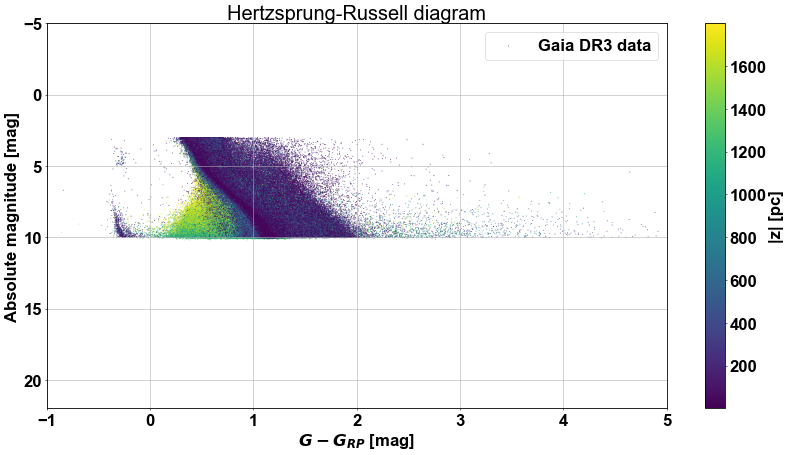

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
scatter = ax[0].scatter(g_rp2[np.where(abs(z_pc2)<=1800)], absolute_magnitude2[np.where(abs(z_pc2)<=1800)], c=np.abs(z_pc2)[np.where(abs(z_pc2)<=1800)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].set_xlim(-1, 5)
ax[0].set_ylim(22, -5)
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('plots/hr_new.png')
fig.set_dpi(50)
plt.show()

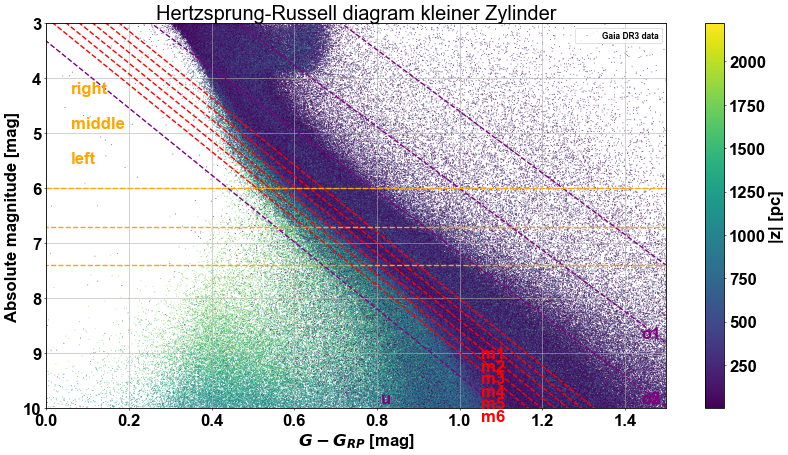

In [208]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
r = 200

scatter = ax[0].scatter(g_rp2[(r_pc2<r)], absolute_magnitude2[(r_pc2<r)], c=np.abs(z_pc2)[(r_pc2<r)], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

x = np.array([-1,2.5])

ax[0].plot(x, (6-7.4)/(0.79-1.04)*(x-1.25)+6, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.79-1.04)*(x-1.0)+6, color='purple', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.79-1.04)*(x-0.79)+6, color='purple', linestyle='--', linewidth=2)

delta = 0.032
ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.67+0*delta)+6, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.67+1*delta)+6, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.67+2*delta)+6, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.67+3*delta)+6, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.67+4*delta)+6, color='red', linestyle='--', linewidth=2)
ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.67+5*delta)+6, color='red', linestyle='--', linewidth=2)

ax[0].plot(x, (6-7.4)/(0.67-0.9)*(x-0.44)+6, color='purple', linestyle='--', linewidth=2)


ax[0].axhline(6, 0, 1.5, color='orange', linestyle='--', linewidth=2)
ax[0].axhline(6.7, min(x), max(x), color='orange', linestyle='--', linewidth=2)
ax[0].axhline(7.4, min(x), max(x), color='orange', linestyle='--', linewidth=2)



ax[0].grid()
ax[0].legend(loc='upper right', fontsize='12')

ax[0].set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram kleiner Zylinder')
ax[0].invert_yaxis()
ax[0].set_xlim(-0.0, 1.5)
ax[0].set_ylim(10, 3)

plt.figtext(0.46, 0.12, 'u', color='purple')

plt.figtext(0.15, 0.6, 'left', color='orange')
plt.figtext(0.15, 0.67, 'middle', color='orange')
plt.figtext(0.15, 0.74, 'right', color='orange')

plt.figtext(0.72, 0.25, 'o1', color='purple')
plt.figtext(0.72, 0.12, 'o2', color='purple')
plt.figtext(0.72, 0.12, 'o3', color='purple')


plt.figtext(0.56, 0.21, 'm1', color='red')
plt.figtext(0.56, 0.185, 'm2', color='red')
plt.figtext(0.56, 0.16, 'm3', color='red')
plt.figtext(0.56, 0.135, 'm4', color='red')
plt.figtext(0.56, 0.11, 'm5', color='red')
plt.figtext(0.56, 0.085, 'm6', color='red')

colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('plots/hr_colour_zoom_new.png')
fig.set_dpi(50)
plt.show()

In [209]:
x = g_rp2

o1 = (6-7.4)/(0.79-1.04)*(x-1.25)+6
o2 = (6-7.4)/(0.79-1.04)*(x-1.0)+6
o3 = (6-7.4)/(0.79-1.04)*(x-0.79)+6

m1 = (6-7.4)/(0.67-0.9)*(x-0.67+0*delta)+6
m2 = (6-7.4)/(0.67-0.9)*(x-0.67+1*delta)+6
m3 = (6-7.4)/(0.67-0.9)*(x-0.67+2*delta)+6
m4 = (6-7.4)/(0.67-0.9)*(x-0.67+3*delta)+6
m5 = (6-7.4)/(0.67-0.9)*(x-0.67+4*delta)+6
m6 = (6-7.4)/(0.67-0.9)*(x-0.67+5*delta)+6

u = (6-7.4)/(0.67-0.9)*(x-0.44)+6

left = 6
middle = 6.7
right = 7.4

''' Spezielle Cuts '''
n33, bins33 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n34, bins34 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o1)&(absolute_magnitude2<=m5)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n37, bins37 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o2)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n38, bins38 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o2)&(absolute_magnitude2<=m5)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n41, bins41 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n42, bins42 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m5)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n45, bins45 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n46, bins46 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n47, bins47 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n48, bins48 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m4)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n49, bins49 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m5)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n50, bins50 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m6)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n51, bins51 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m1)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n52, bins52 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m2)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n53, bins53 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m3)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n54, bins54 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m4)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n55, bins55 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m5)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n56, bins56 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m6)&(absolute_magnitude2<=u)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

n60, bins60 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m2)&(absolute_magnitude2<=right)&(absolute_magnitude2>=middle)], bins=40)
n61, bins61 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m2)&(absolute_magnitude2<=middle)&(absolute_magnitude2>=left)], bins=40)

n63, bins63 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=middle)], bins=40)
n64, bins64 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=middle)&(absolute_magnitude2>=left)], bins=40)

n70, bins70 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m1)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)
n71, bins71 = np.histogram(z_pc2[(r_pc2<r)&(absolute_magnitude2>=m1)&(absolute_magnitude2<=m6)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)], bins=40)

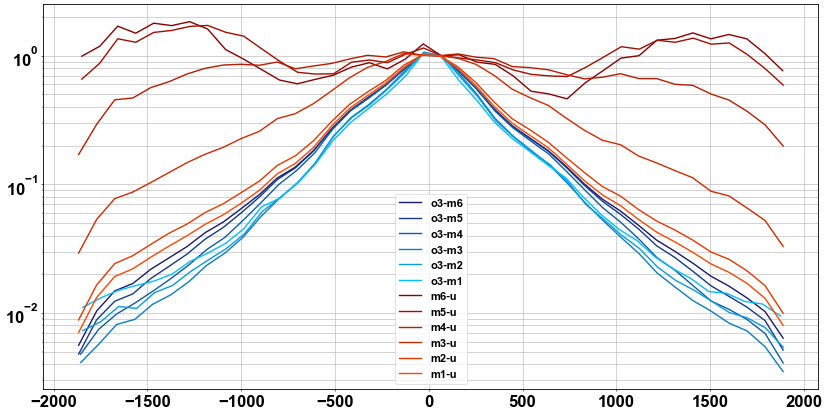

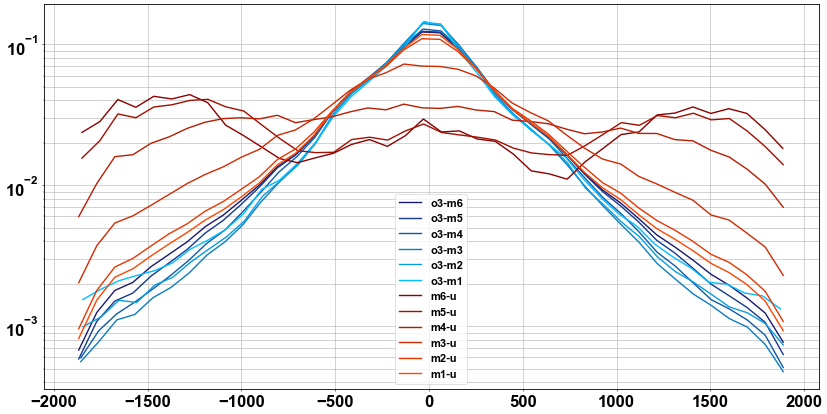

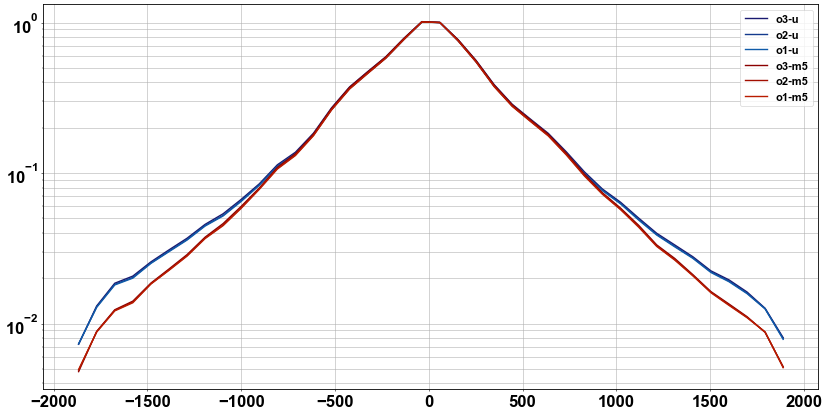

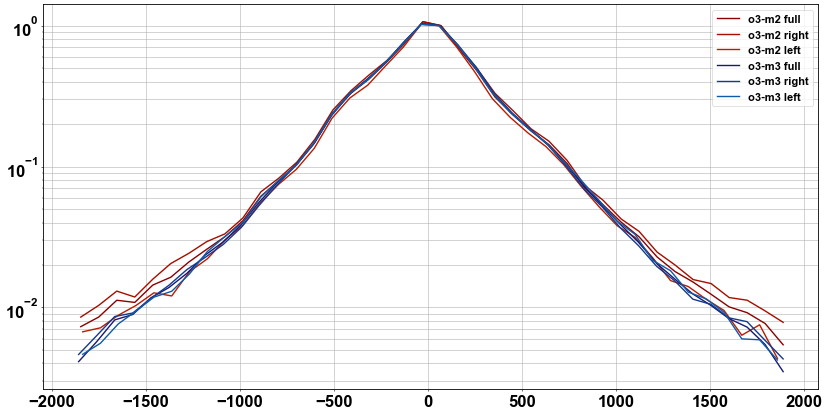

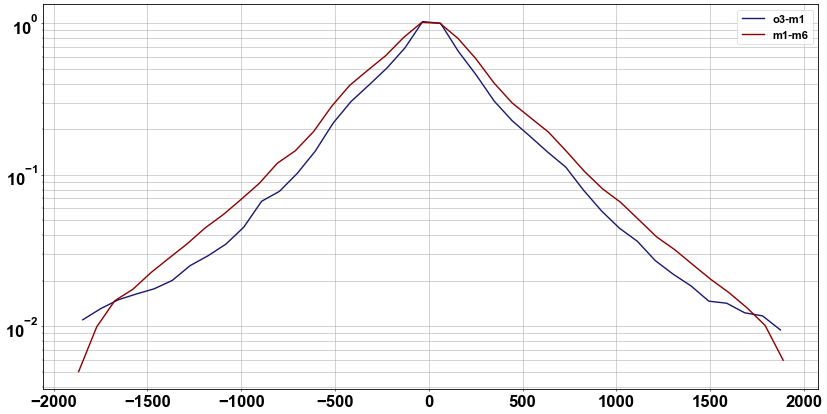

In [210]:
color1 = "#191970"
color6 = "#00BFFF"
color11 = "#8B0000"
color16 = "#FF4500"

rgb1 = mcolors.hex2color(color1)
rgb6 = mcolors.hex2color(color6)
rgb11 = mcolors.hex2color(color11)
rgb16 = mcolors.hex2color(color16)

rgb2 = tuple(c1 + 1 * (c2 - c1) / 5 for c1, c2 in zip(rgb1, rgb6))
rgb3 = tuple(c1 + 2 * (c2 - c1) / 5 for c1, c2 in zip(rgb1, rgb6))
rgb4 = tuple(c1 + 3 * (c2 - c1) / 5 for c1, c2 in zip(rgb1, rgb6))
rgb5 = tuple(c1 + 4 * (c2 - c1) / 5 for c1, c2 in zip(rgb1, rgb6))
rgb12 = tuple(c1 + 1 * (c2 - c1) / 5 for c1, c2 in zip(rgb11, rgb16))
rgb13 = tuple(c1 + 2 * (c2 - c1) / 5 for c1, c2 in zip(rgb11, rgb16))
rgb14 = tuple(c1 + 3 * (c2 - c1) / 5 for c1, c2 in zip(rgb11, rgb16))
rgb15 = tuple(c1 + 4 * (c2 - c1) / 5 for c1, c2 in zip(rgb11, rgb16))

color2 = mcolors.to_hex(rgb2)
color3 = mcolors.to_hex(rgb3)
color4 = mcolors.to_hex(rgb4)
color5 = mcolors.to_hex(rgb5)
color12 = mcolors.to_hex(rgb12)
color13 = mcolors.to_hex(rgb13)
color14 = mcolors.to_hex(rgb14)
color15 = mcolors.to_hex(rgb15)




fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot((bins50[:-1]+bins50[1:])/2, n50/n50[20], label='o3-m6', color=color1)
ax.plot((bins49[:-1]+bins49[1:])/2, n49/n49[20], label='o3-m5', color=color2)
ax.plot((bins48[:-1]+bins48[1:])/2, n48/n48[20], label='o3-m4', color=color3)
ax.plot((bins47[:-1]+bins47[1:])/2, n47/n47[20], label='o3-m3', color=color4)
ax.plot((bins46[:-1]+bins46[1:])/2, n46/n46[20], label='o3-m2', color=color5)
ax.plot((bins45[:-1]+bins45[1:])/2, n45/n45[20], label='o3-m1', color=color6)

ax.plot((bins56[:-1]+bins56[1:])/2, n56/n56[20], label='m6-u', color=color11)
ax.plot((bins55[:-1]+bins55[1:])/2, n55/n55[20], label='m5-u', color=color12)
ax.plot((bins54[:-1]+bins54[1:])/2, n54/n54[20], label='m4-u', color=color13)
ax.plot((bins53[:-1]+bins53[1:])/2, n53/n53[20], label='m3-u', color=color14)
ax.plot((bins52[:-1]+bins52[1:])/2, n52/n52[20], label='m2-u', color=color15)
ax.plot((bins51[:-1]+bins51[1:])/2, n51/n51[20], label='m1-u', color=color16)

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
plt.savefig('plots/selections_u.png')
fig.set_dpi(50)
plt.show()




fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot((bins50[:-1]+bins50[1:])/2, n50/np.sum(n50), label='o3-m6', color=color1)
ax.plot((bins49[:-1]+bins49[1:])/2, n49/np.sum(n49), label='o3-m5', color=color2)
ax.plot((bins48[:-1]+bins48[1:])/2, n48/np.sum(n48), label='o3-m4', color=color3)
ax.plot((bins47[:-1]+bins47[1:])/2, n47/np.sum(n47), label='o3-m3', color=color4)
ax.plot((bins46[:-1]+bins46[1:])/2, n46/np.sum(n46), label='o3-m2', color=color5)
ax.plot((bins45[:-1]+bins45[1:])/2, n45/np.sum(n45), label='o3-m1', color=color6)

ax.plot((bins56[:-1]+bins56[1:])/2, n56/np.sum(n56), label='m6-u', color=color11)
ax.plot((bins55[:-1]+bins55[1:])/2, n55/np.sum(n55), label='m5-u', color=color12)
ax.plot((bins54[:-1]+bins54[1:])/2, n54/np.sum(n54), label='m4-u', color=color13)
ax.plot((bins53[:-1]+bins53[1:])/2, n53/np.sum(n53), label='m3-u', color=color14)
ax.plot((bins52[:-1]+bins52[1:])/2, n52/np.sum(n52), label='m2-u', color=color15)
ax.plot((bins51[:-1]+bins51[1:])/2, n51/np.sum(n51), label='m1-u', color=color16)

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()




fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot((bins41[:-1]+bins41[1:])/2, n41/n41[20], label='o3-u', color=color1)
ax.plot((bins37[:-1]+bins37[1:])/2, n37/n37[20], label='o2-u', color=color2)
ax.plot((bins33[:-1]+bins33[1:])/2, n33/n33[20], label='o1-u', color=color3)

ax.plot((bins42[:-1]+bins42[1:])/2, n42/n42[20], label='o3-m5', color=color11)
ax.plot((bins38[:-1]+bins38[1:])/2, n38/n38[20], label='o2-m5', color=color12)
ax.plot((bins34[:-1]+bins34[1:])/2, n34/n34[20], label='o1-m5', color=color13)

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
plt.savefig('plots/selections_o.png')
fig.set_dpi(50)
plt.show()





fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot((bins46[:-1]+bins46[1:])/2, n46/n46[20], label='o3-m2 full', color=color11)
ax.plot((bins60[:-1]+bins60[1:])/2, n60/n60[20], label='o3-m2 right', color=color12)
ax.plot((bins61[:-1]+bins61[1:])/2, n61/n61[20], label='o3-m2 left', color=color13)

ax.plot((bins47[:-1]+bins47[1:])/2, n47/n47[20], label='o3-m3 full', color=color1)
ax.plot((bins63[:-1]+bins63[1:])/2, n63/n63[20], label='o3-m3 right', color=color2)
ax.plot((bins64[:-1]+bins64[1:])/2, n64/n64[20], label='o3-m3 left', color=color3)

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot((bins70[:-1]+bins70[1:])/2, n70/n70[20], label='o3-m1', color=color1)
ax.plot((bins71[:-1]+bins71[1:])/2, n71/n71[20], label='m1-m6', color=color11)

ax.set_yscale('log')
plt.grid(which='both')
plt.legend(fontsize='16')
fig.set_dpi(50)
plt.show()


cut = (r_pc2<200)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=right)&(absolute_magnitude2>=left)
sampleleft = (absolute_magnitude2>=left) & (absolute_magnitude2<=middle)
sampleright = (absolute_magnitude2>=middle) & (absolute_magnitude2<=right)

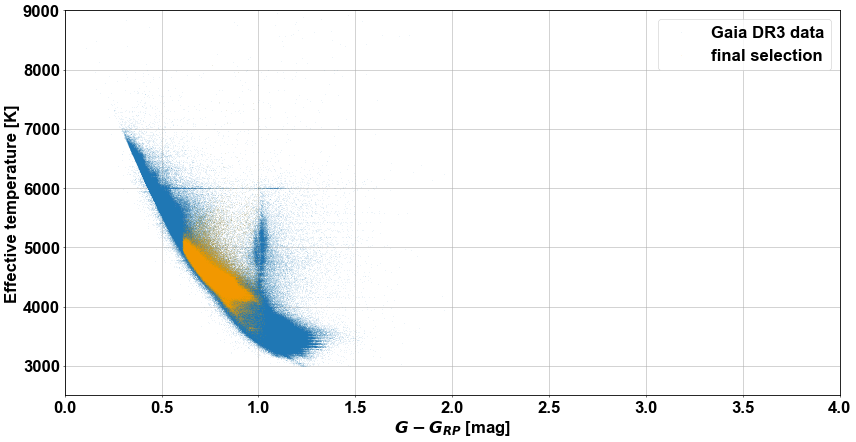

In [214]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot(g_rp2, teff2, '.', markersize=1, label='Gaia DR3 data', alpha=0.1)
ax.plot(g_rp2[cut], teff2[cut], '.', markersize=1, label='final selection', color='orange', alpha=0.1)
ax.set_xlabel(rf'$G-G_{{RP}}$ [mag]')
ax.set_ylabel('Effective temperature [K]')
ax.set_ylim(2500, 9000)
ax.set_xlim(0, 4)
plt.grid(which='both')
plt.legend()
plt.savefig('plots/teff_bp_rp_new.png')
fig.set_dpi(50)
plt.show()

158684
161216


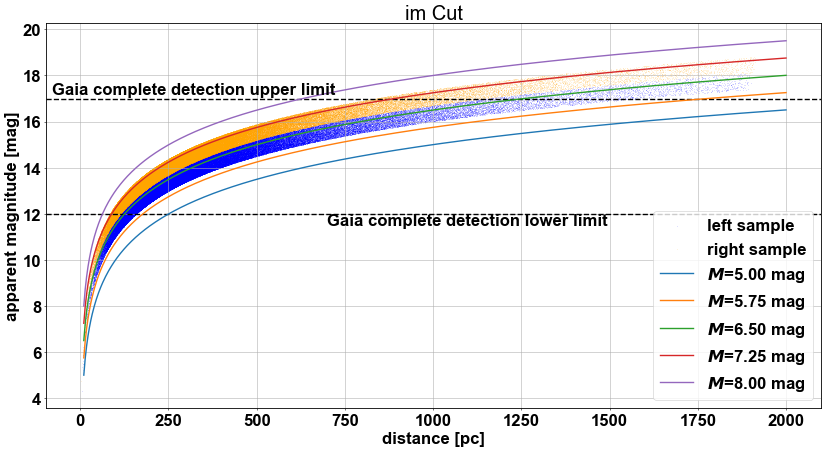

In [212]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]

ax[0].axhline(y=17, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)
scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleleft]), apparent_magnitude2[cut&sampleleft], marker='.', c='blue', s=0.1, label='left sample', alpha=0.5)
scatter = ax[0].scatter(np.abs(dist_pc2[cut&sampleright]), apparent_magnitude2[cut&sampleright], marker='.', c='orange', s=0.1, label='right sample', alpha=0.5)
print(len(np.abs(dist_pc2[cut&sampleright])))
print(len(np.abs(dist_pc2[cut&sampleleft])))
z = np.linspace(0, 2000, 100)
Ms = np.linspace(5.0, 8.0, 5) # absolute magnitude in mag
dist = np.linspace(10, 2000, 1000) # pc
for M in Ms:
    m = M_d_to_m(M, dist)
    plt.plot(dist, m, label=r"$M$={:.2f} mag".format(M))
plt.text(-80, 17.2, "Gaia complete detection upper limit")
plt.text(700, 11.5, "Gaia complete detection lower limit")
ax[0].grid()
ax[0].legend(loc='lower right')
ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
ax[0].set_title('im Cut')

# ax[0].axvline(x=190, color='brown', linestyle=':', linewidth=1.5)
# ax[0].axvline(x=125, color='brown', linestyle=':', linewidth=1.5)
# ax[0].axvline(x=870, color='brown', linestyle=':', linewidth=1.5)
# ax[0].axvline(x=950, color='brown', linestyle=':', linewidth=1)
# ax[0].axvline(x=1250, color='brown', linestyle=':', linewidth=1.5)
# ax[0].axvline(x=1400, color='brown', linestyle=':', linewidth=1)
# ax[0].axvline(x=1600, color='brown', linestyle=':', linewidth=1)

plt.savefig('plots/absmag_dist_new.png')
fig.set_dpi(50)
plt.show()

In [213]:
# Check if correction function is defined on full sample
print(len(apparent_magnitude2[cut&(abs(z_pc2)>150)]))
zpvals2 = zpt.get_zpt(apparent_magnitude2[cut&(z_pc2>150)], nueff2[cut&(z_pc2>150)], psc2[cut&(z_pc2>150)], ecl_lat2[cut&(z_pc2>150)], soltype2[cut&(z_pc2>150)])
# print(min(psc2[cut&(z_pc2>150)&np.isfinite(psc2)]))
# print(max(psc2[cut&(z_pc2>150)&np.isfinite(psc2)]))

192370


C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:233: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(
